In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from core.universe import PortfolioUniverse
from data.data_loader import download_market_data
from features.stock_features import compute_stock_features
from features.portfolio_features import compute_portfolio_features
from targets.sharpe_target import compute_forward_sharpe
from models.ranking_model import prepare_data, train_ranking_model, predict_scores
from models.evaluation import evaluate_ranking
from conviction.conviction_scores import (
    softmax_conviction,
    minmax_conviction,
    zscore_conviction,
    rank_conviction,
    signal_to_noise_conviction,
)

Matplotlib is building the font cache; this may take a moment.
/Users/user/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
universe = PortfolioUniverse.make_many("sample_portfolios.json")
universe.resolve_portfolios_inplace()

# show all portfolios and their weights
for p in universe.portfolios:
    print(f"{p.portfolio_id} - {p.name}")
    print(f"  Weights: {p.resolved_portfolio_weights}\n")

portfolio_001 - US Mega Cap Growth
  Weights: {'AAPL': 0.22, 'MSFT': 0.22, 'NVDA': 0.2, 'AMZN': 0.18, 'GOOGL': 0.18}

portfolio_002 - Semiconductor Leaders
  Weights: {'NVDA': 0.24, 'AMD': 0.2, 'TSM': 0.2, 'AVGO': 0.18, 'QCOM': 0.18}

portfolio_003 - Cloud Platforms
  Weights: {'MSFT': 0.24000000000000005, 'AMZN': 0.22000000000000006, 'GOOGL': 0.18000000000000002, 'META': 0.18000000000000002, 'ORCL': 0.18000000000000002}

portfolio_004 - Consumer Tech Mix
  Weights: {'AAPL': 0.22, 'AMZN': 0.22, 'TSLA': 0.2, 'NFLX': 0.18, 'META': 0.18}

portfolio_005 - Enterprise Software
  Weights: {'MSFT': 0.24, 'ADBE': 0.2, 'CRM': 0.2, 'INTU': 0.18, 'NOW': 0.18}



In [3]:
prices, volumes = download_market_data(universe)
print(f"Data: {prices.shape[0]} trading days, {prices.shape[1]} tickers")
print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.head()

[*********************100%***********************]  17 of 17 completed


Data: 1507 trading days, 17 tickers
Range: 2020-01-02 to 2025-12-30


Ticker,AAPL,ADBE,AMD,AMZN,AVGO,CRM,GOOGL,INTU,META,MSFT,NFLX,NOW,NVDA,ORCL,QCOM,TSLA,TSM
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.400505,334.429993,49.099998,94.900497,27.735554,164.985413,67.873032,255.523529,208.324768,152.158386,32.980999,58.248001,5.970755,49.321243,77.151024,28.684000,53.779682
2020-01-03,71.696632,331.809998,48.599998,93.748497,27.030098,164.175232,67.517960,253.814697,207.222488,150.263733,32.590000,58.220001,5.875187,49.147530,75.698303,29.534000,52.006145
2020-01-06,72.267921,333.709991,48.389999,95.143997,26.989666,171.367828,69.317596,255.763535,211.125214,150.652145,33.583000,58.574001,5.899825,49.403522,75.254684,30.102667,51.405991
2020-01-07,71.928055,333.390015,48.250000,95.343002,26.896749,173.887238,69.183701,255.821198,211.582031,149.278564,33.075001,58.582001,5.971252,49.513229,77.394608,31.270666,52.239021
2020-01-08,73.085106,337.869995,47.830002,94.598503,26.561234,175.201248,69.676132,261.975006,213.727051,151.656296,33.925999,59.130001,5.982451,49.706062,77.168427,32.809334,52.624184


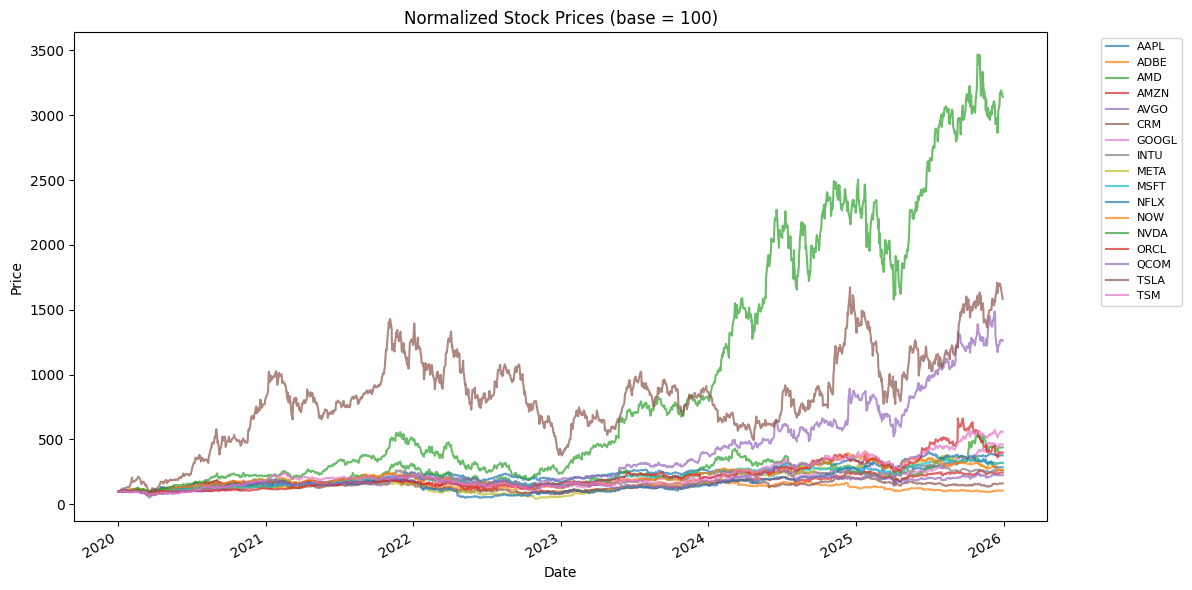

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
# normalize prices to start at 100for comparison
normalized = prices / prices.iloc[0] * 100
normalized.plot(ax=ax, alpha=0.7)
ax.set_title("Normalized Stock Prices (base = 100)")
ax.set_ylabel("Price")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
stock_features = compute_stock_features(prices, volumes)
portfolio_features = compute_portfolio_features(stock_features, universe.portfolios)

print(f"Portfolio features: {portfolio_features.shape}")
portfolio_features.head(10)

Portfolio features: (7235, 7)


,date,portfolio_id,momentum_20,momentum_60,volatility_20,volatility_60,avg_volume_20
0,2020-03-30,portfolio_001,-0.086471,-0.034300,0.064558,0.041546,258988803.7
1,2020-03-31,portfolio_001,-0.057264,-0.027878,0.064145,0.041545,260325698.3
2,2020-04-01,portfolio_001,-0.140470,-0.084224,0.064055,0.041987,260460056.8
3,2020-04-02,portfolio_001,-0.091209,-0.063301,0.063974,0.042098,261540411.4
4,2020-04-03,portfolio_001,-0.091107,-0.088003,0.064001,0.042160,261192930.8
5,2020-04-06,portfolio_001,0.051914,-0.027973,0.064578,0.043394,260939030.8
6,2020-04-07,portfolio_001,-0.019710,-0.038700,0.063230,0.043436,261740138.6
7,2020-04-08,portfolio_001,0.046990,-0.034466,0.062409,0.043469,260696479.6
8,2020-04-09,portfolio_001,0.156593,-0.024997,0.057732,0.043450,252934806.1
9,2020-04-13,portfolio_001,0.067745,-0.001752,0.053035,0.043654,246631659.8


In [6]:
forward_sharpe = compute_forward_sharpe(prices, universe.portfolios)
forward_sharpe.dropna().head(10)

,date,portfolio_id,forward_sharpe
0,2020-01-02,portfolio_001,0.166720
1,2020-01-03,portfolio_001,0.281827
2,2020-01-06,portfolio_001,0.308902
3,2020-01-07,portfolio_001,0.328487
4,2020-01-08,portfolio_001,0.352951
5,2020-01-09,portfolio_001,0.295026
6,2020-01-10,portfolio_001,0.371481
7,2020-01-13,portfolio_001,0.310278
8,2020-01-14,portfolio_001,0.416431
9,2020-01-15,portfolio_001,0.389767


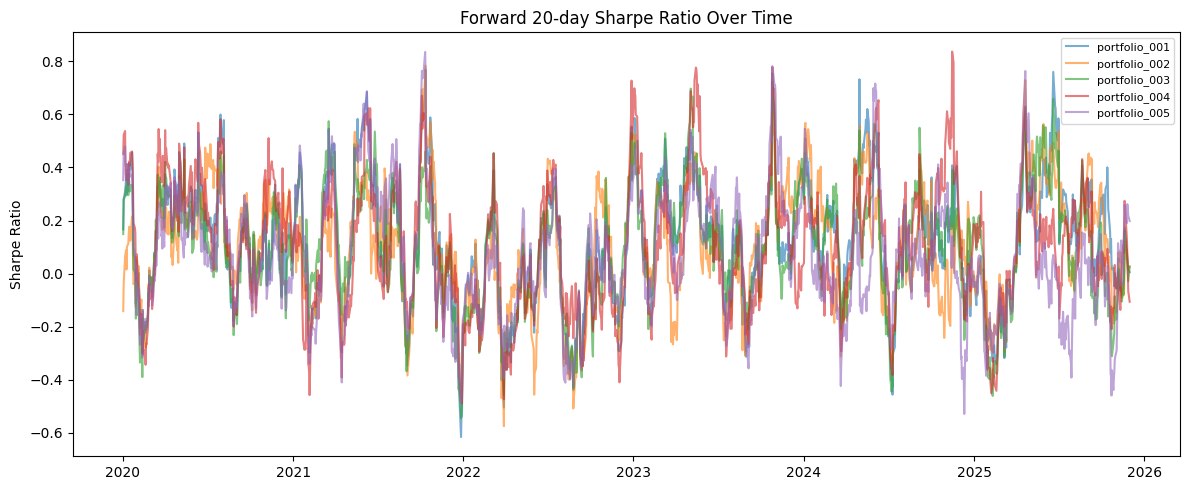

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for pid in forward_sharpe["portfolio_id"].unique():
    subset = forward_sharpe[forward_sharpe["portfolio_id"] == pid]
    ax.plot(subset["date"], subset["forward_sharpe"], label=pid, alpha=0.6)
ax.set_title("Forward 20-day Sharpe Ratio Over Time")
ax.set_ylabel("Sharpe Ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
X_train, y_train, group_train, X_test, y_test, group_test, test_df = prepare_data(portfolio_features, forward_sharpe)
print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

model = train_ranking_model(X_train, y_train, group_train)

scores = predict_scores(model, X_test)
test_df = test_df.copy()
test_df["predicted_score"] = scores
print(f"Score range: [{scores.min():.4f}, {scores.max():.4f}]")

Train: 4730 rows, Test: 2405 rows
Score range: [-0.4629, 0.5680]


In [9]:
eval_df = evaluate_ranking(test_df)

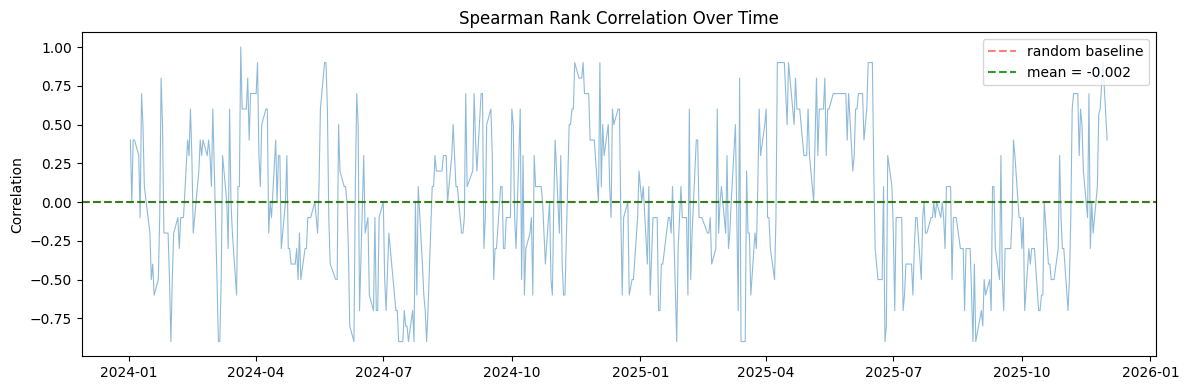

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eval_df["date"], eval_df["spearman_corr"], alpha=0.5, linewidth=0.8)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='random baseline')
ax.axhline(y=eval_df["spearman_corr"].mean(), color='green', linestyle='--', alpha=0.8, label=f'mean = {eval_df["spearman_corr"].mean():.3f}')
ax.set_title("Spearman Rank Correlation Over Time")
ax.set_ylabel("Correlation")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
all_convictions = []
for date, group in test_df.groupby("date"):
    s = group["predicted_score"].values
    row = group[["date", "portfolio_id", "predicted_score"]].copy()
    row["softmax"] = softmax_conviction(s)
    row["minmax"] = minmax_conviction(s)
    row["zscore"] = zscore_conviction(s)
    row["rank"] = rank_conviction(s)
    row["signal_to_noise"] = signal_to_noise_conviction(s, group["volatility_20"].values)
    all_convictions.append(row)

conviction_df = pd.concat(all_convictions).reset_index(drop=True)

# show sample
sample_date = conviction_df["date"].iloc[0]
sample = conviction_df[conviction_df["date"] == sample_date]
print(f"Conviction scores for {sample_date.date()}:\n")
sample[["portfolio_id", "predicted_score", "softmax", "minmax", "zscore", "rank", "signal_to_noise"]]

Conviction scores for 2024-01-02:



,portfolio_id,predicted_score,softmax,minmax,zscore,rank,signal_to_noise
0,portfolio_001,0.120643,0.208879,0.735126,0.584682,0.8,8.887828
1,portfolio_002,-0.009813,0.183332,0.097350,-1.052406,0.4,-0.469250
2,portfolio_003,0.114328,0.207564,0.704253,0.505436,0.6,6.966550
3,portfolio_004,-0.029726,0.179717,0.000000,-1.302291,0.2,-1.902059
4,portfolio_005,0.174822,0.220508,1.000000,1.264579,1.0,12.056460


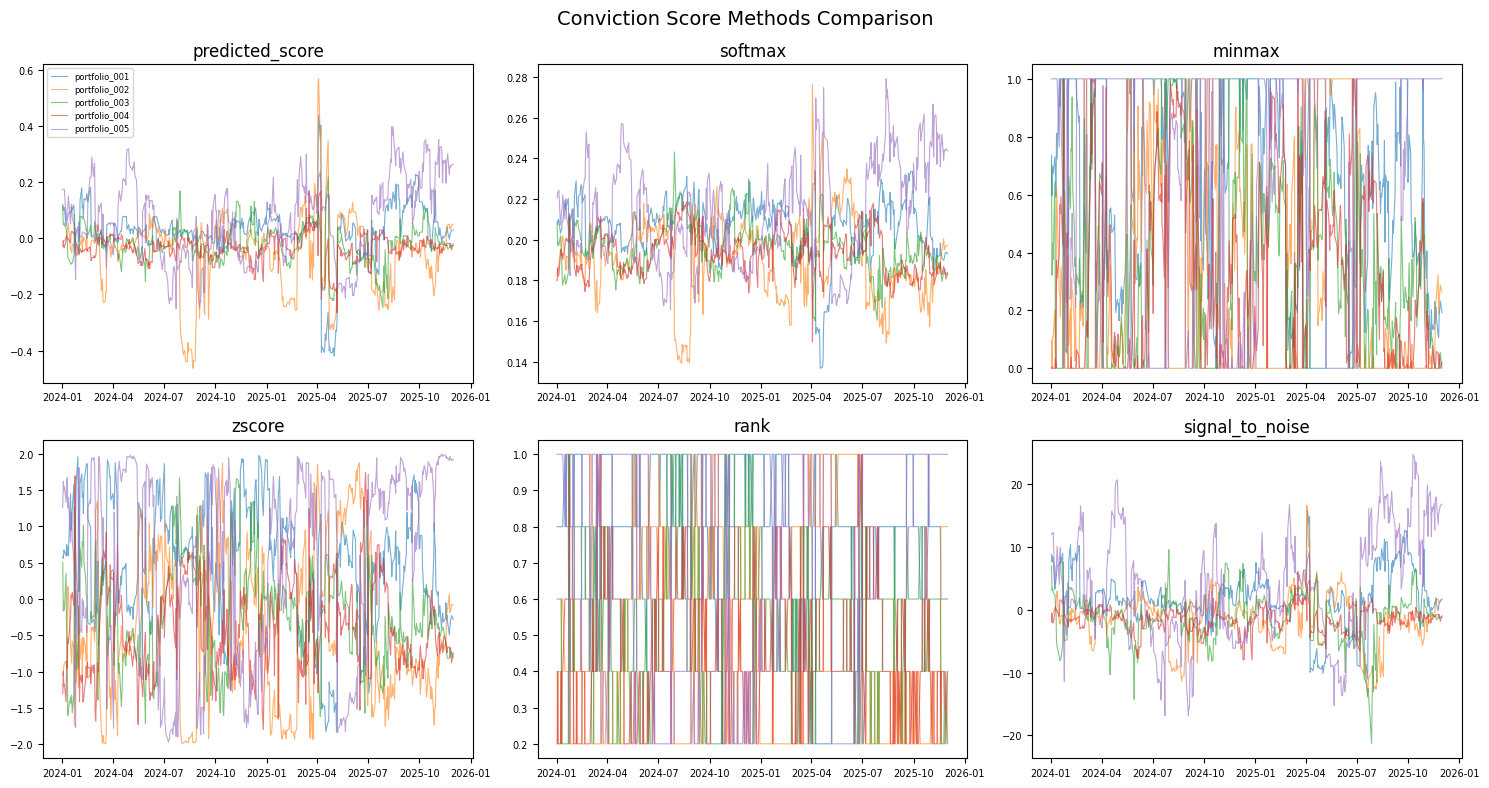

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
methods = ["predicted_score", "softmax", "minmax", "zscore", "rank", "signal_to_noise"]

for ax, method in zip(axes.flatten(), methods):
    for pid in conviction_df["portfolio_id"].unique():
        subset = conviction_df[conviction_df["portfolio_id"] == pid]
        ax.plot(subset["date"], subset[method], label=pid, alpha=0.6, linewidth=0.8)
    ax.set_title(method)
    ax.tick_params(labelsize=7)

axes[0][0].legend(fontsize=6)
plt.suptitle("Conviction Score Methods Comparison", fontsize=14)
plt.tight_layout()
plt.show()